In [1]:
import pandas as pd
df=pd.read_csv(r'/content/drive/MyDrive/Datasets/advertising.csv')
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [2]:
x=df.iloc[:,:-1]
y=df['Sales']

<Axes: xlabel='TV', ylabel='Sales'>

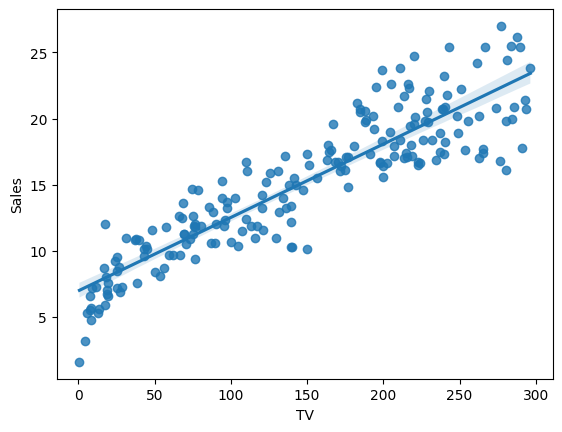

In [3]:
import seaborn as sns
sns.regplot(x=df['TV'],y=df['Sales'])

<Axes: xlabel='Radio', ylabel='Sales'>

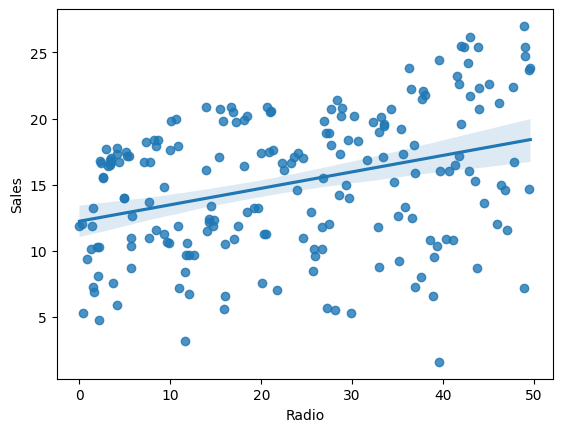

In [4]:
sns.regplot(x=df['Radio'],y=df['Sales'])

<Axes: xlabel='Newspaper', ylabel='Sales'>

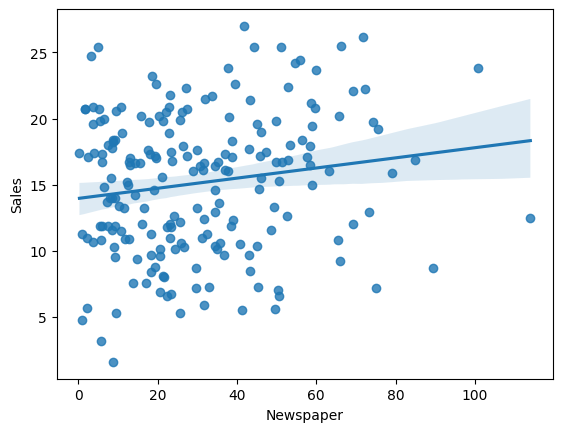

In [5]:
sns.regplot(x=df['Newspaper'],y=df['Sales'])

In [6]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


In [7]:
from sklearn.model_selection import train_test_split
x_tr,x_te,y_tr,y_te=train_test_split(x,y,test_size=0.30,random_state=11)

In [8]:
from sklearn.linear_model import LinearRegression
lnr=LinearRegression()
lnr.fit(x_tr,y_tr)

LinearRegression()

In [10]:
y_pred=lnr.predict(x_te)

In [11]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,root_mean_squared_error
print('r2 score',r2_score(y_te,y_pred))
print('MSE',mean_squared_error(y_te,y_pred))
print('MAE',mean_absolute_error(y_te,y_pred))
print('RMSE',root_mean_squared_error(y_te,y_pred))

r2 score 0.873218749161135
MSE 3.853212900755712
MAE 1.4085048291195874
RMSE 1.9629602392192542


In [13]:
y_new=lnr.predict([[180,30,45]])
y_new

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([17.62373589])

In [14]:
lnr.coef_

array([ 0.05431123,  0.10162066, -0.0020213 ])

In [15]:
lnr.intercept_

np.float64(4.890053786492084)

In [18]:
4.890053786492084+0.05431123*222.4+3.4*0.10162066+13.1*-0.0020213

17.287902552492085

In [19]:
y_pred

array([17.28790168, 21.34692215, 14.73169831, 12.62610671,  7.12247417,
       19.38350799, 10.68409844,  8.0583846 , 11.08071319, 12.12373654,
       20.5913394 , 12.43389761,  8.93466445, 17.81904661, 19.22531505,
       13.45880929, 12.06124329,  7.95568996, 21.83176804, 21.08845408,
       10.34851931, 10.69565501, 11.7962277 , 12.12869872, 23.31021434,
       16.90987748, 14.30204287,  9.1644474 , 24.42697532, 17.1968919 ,
       12.27227593, 10.267888  , 19.4847321 , 15.60314493, 22.07975471,
       23.82659833, 13.05510281, 12.21688854, 19.38991015, 15.19427979,
       17.49462186, 22.57120198, 23.5863565 , 16.80682726, 24.81907943,
       18.9814846 , 22.05214918, 17.02176477, 24.4727823 , 20.80054121,
       23.6470836 , 17.21469559, 15.06677641, 16.62601197, 21.47295409,
        6.17697863, 15.9926432 , 14.30830111, 15.96279895, 14.90035934])

In [20]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
x_tr_scaled=scaler.fit_transform(x_tr)
x_te_scaled=scaler.transform(x_te)

In [22]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor()
knn.fit(x_tr_scaled,y_tr)
y_knn=knn.predict(x_te_scaled)
r2_score(y_te,y_knn)

0.8690038943131182